In [10]:
from datasets import load_dataset

longmemeval_queries = load_dataset("weaviate/longmemeval-s-cleaned", "queries")

Generating train split: 100%|██████████| 500/500 [00:00<00:00, 26529.44 examples/s]


In [12]:
longmemeval_queries["train"][0]

{'question_id': 'e47becba',
 'question': 'What degree did I graduate with?',
 'question_date': '2023/05/30 (Tue) 23:40',
 'answer': 'Business Administration',
 'answer_session_ids': ['answer_280352e9'],
 'tenant_id': 'e47becba'}

In [13]:
longmemeval_docs = load_dataset("weaviate/longmemeval-s-cleaned", "docs")
longmemeval_docs["train"][0]

Generating train split: 100%|██████████| 23867/23867 [00:02<00:00, 11303.64 examples/s]


{'tenant_id': 'e47becba',
 'session_id': 'sharegpt_yywfIrx_0',
 'session_date': '2023/05/20 (Sat) 02:21',
 'session_text': "user: The farmer needs to transport a fox, a chicken, and some grain across a river using a boat. The fox cannot be left alone with the chicken, and the chicken cannot be left alone with the grain. The boat can only hold one item at a time, and the river is too dangerous to cross multiple times. Can you help the farmer transport all three items across the river without any of them getting eaten? Remember, strategic thinking and planning are key to solving this puzzle. If you're stuck, try thinking about how you would solve the puzzle yourself, and use that as a starting point. Be careful not to leave the chicken alone with the fox, or the chicken and the grain alone together, as this will result in a failed solution. Good luck!\nassistant: To solve this puzzle, the farmer can follow these steps:\n\n1. First, the farmer should take the chicken across the river usin

Session text token counts:
Min: 6
Max: 17263
Mean: 2180.1
Median: 2176.0
Std: 1128.6


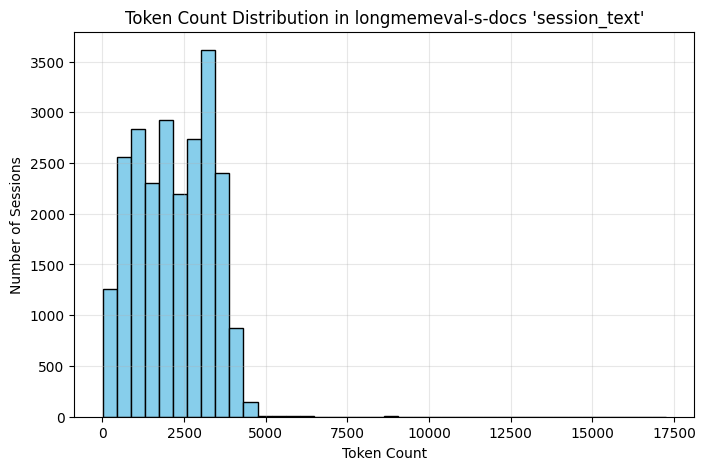

In [15]:
import tiktoken
import matplotlib.pyplot as plt

# Use OpenAI's cl100k_base encoding (works for most English text as GPT-3.5/4 default)
encoding = tiktoken.get_encoding("cl100k_base")

# Helper: encode with endoftext allowed as normal, disables special token errors
def safe_encode(text):
    try:
        # Allow all special tokens to be treated as normal text
        return encoding.encode(text, disallowed_special=())
    except Exception as e:
        print(f"Encoding error for text (first 60 chars): {repr(text[:60])} -- {e}")
        return []

# Collect token counts for all session_texts in the docs split
token_counts = [
    len(safe_encode(doc["session_text"]))
    for doc in longmemeval_docs["train"]
]

# Display basic stats
import numpy as np
print("Session text token counts:")
print(f"Min: {np.min(token_counts)}")
print(f"Max: {np.max(token_counts)}")
print(f"Mean: {np.mean(token_counts):.1f}")
print(f"Median: {np.median(token_counts)}")
print(f"Std: {np.std(token_counts):.1f}")

# Plot histogram of token count distribution
plt.figure(figsize=(8, 5))
plt.hist(token_counts, bins=40, color='skyblue', edgecolor='black')
plt.title("Token Count Distribution in longmemeval-s-docs 'session_text'")
plt.xlabel("Token Count")
plt.ylabel("Number of Sessions")
plt.grid(True, alpha=0.3)
plt.show()